# Find the Flag! — Decision Trees
### Codecademy ML Career Path Project

Can you guess which continent a flag comes from?

What are some of the features that would clue you in? Maybe some of the colors are good indicators. The presence or absence of certain shapes could give you a hint. In this project, we'll use **decision trees** to try to predict the continent of flags based on several of these features.

We'll explore which features are the best to use and the best way to create your decision tree.

**Dataset:** [UCI Machine Learning Repository — Flags](https://archive.ics.uci.edu/ml/datasets/Flags) (saved locally as `flag.data`)

Some of the input and output features of interest:

| Feature | Description |
|---|---|
| `name` | Name of the country concerned |
| `landmass` | 1=N.America, 2=S.America, 3=Europe, 4=Africa, 5=Asia, 6=Oceania |
| `bars` | Number of vertical bars in the flag |
| `stripes` | Number of horizontal stripes in the flag |
| `colours` | Number of different colours in the flag |
| `red` | 0 if red absent, 1 if red present in the flag |
| `mainhue` | Predominant colour in the flag |
| `circles` | Number of circles in the flag |
| `crosses` | Number of (upright) crosses |
| `saltires` | Number of diagonal crosses |
| `quarters` | Number of quartered sections |
| `sunstars` | Number of sun or star symbols |

## Setup

Imports, load the dataset into `df`, and define the list of predictor variables `var`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

cols = ['name','landmass','zone', 'area', 'population', 'language','religion','bars','stripes','colours',
'red','green','blue','gold','white','black','orange','mainhue','circles',
'crosses','saltires','quarters','sunstars','crescent','triangle','icon','animate','text','topleft','botright']

# Loaded from the local copy of the UCI flags dataset
df = pd.read_csv("flag.data", names=cols)

# variable names to use as predictors
var = ['red', 'green', 'blue', 'gold', 'white', 'black', 'orange', 'mainhue', 'bars', 'stripes',
       'circles', 'crosses', 'saltires', 'quarters', 'sunstars', 'triangle', 'animate']

df.head()

,name,landmass,zone,area,population,language,religion,bars,stripes,colours,...,saltires,quarters,sunstars,crescent,triangle,icon,animate,text,topleft,botright
0,Afghanistan,5,1,648,16,10,2,0,3,5,...,0,0,1,0,0,1,0,0,black,green
1,Albania,3,1,29,3,6,6,0,0,3,...,0,0,1,0,0,0,1,0,red,red
2,Algeria,4,1,2388,20,8,2,2,0,3,...,0,0,1,1,0,0,0,0,green,white
3,American-Samoa,6,3,0,0,1,1,0,0,5,...,0,0,0,0,1,1,1,0,blue,red
4,Andorra,3,1,0,0,6,0,3,0,3,...,0,0,0,0,0,0,0,0,blue,red


## Investigate the data

### Task 1

We will build a decision tree classifier to predict what continent a particular flag comes from. Before that, we want to understand the distribution of flags by continent. Calculate the count of flags by landmass value.

*Hint: use `df['landmass'].value_counts()`.*

In [2]:
# Print number of countries by landmass, or continent
print(df['landmass'].value_counts())

landmass
4    52
5    39
3    35
1    31
6    20
2    17
Name: count, dtype: int64


### Task 2

Rather than looking at all six continents, we will focus on just two, **Europe (3)** and **Oceania (6)**. Create a new dataframe with only flags from Europe and Oceania.

In [3]:
# Create a new dataframe with only flags from Europe and Oceania
df_36 = df[df["landmass"].isin(([3,6]))]
df_36.head() 

,name,landmass,zone,area,population,language,religion,bars,stripes,colours,...,saltires,quarters,sunstars,crescent,triangle,icon,animate,text,topleft,botright
1,Albania,3,1,29,3,6,6,0,0,3,...,0,0,1,0,0,0,1,0,red,red
3,American-Samoa,6,3,0,0,1,1,0,0,5,...,0,0,0,0,1,1,1,0,blue,red
4,Andorra,3,1,0,0,6,0,3,0,3,...,0,0,0,0,0,0,0,0,blue,red
10,Australia,6,2,7690,15,1,1,0,0,3,...,1,1,6,0,0,0,0,0,white,blue
11,Austria,3,1,84,8,4,0,0,3,2,...,0,0,0,0,0,0,0,0,red,red


> **💡 Q&A — boolean mask vs. filtered dataframe**
>
> `df["landmass"].isin([3,6])` by itself is a **boolean mask** — a Series of `True`/`False`, one per row — not a dataframe of rows. To actually filter, the mask goes *inside* the square brackets of `df`:
>
> ```python
> df_36 = df[df["landmass"].isin([3,6])]
> ```
>
> The outer `df[...]` does the filtering; the inner expression decides which rows survive (only the `True` ones). Sanity check: `df_36.shape` should be `(55, 30)` — 35 European + 20 Oceanian flags.

### Task 3

Given the list of predictors in the list `var`, print the average values of each for these two continents. Note which predictors have very different averages.

In [4]:
# Print the average values of the predictors for Europe and Oceania
print(df_36.groupby("landmass")[var].mean(numeric_only=True).T)

landmass         3     6
red       0.828571  0.80
green     0.200000  0.20
blue      0.514286  0.80
gold      0.428571  0.60
white     0.771429  0.95
black     0.171429  0.15
orange    0.057143  0.15
bars      0.628571  0.00
stripes   1.285714  0.40
circles   0.028571  0.15
crosses   0.285714  0.40
saltires  0.028571  0.30
quarters  0.028571  0.40
sunstars  0.142857  3.30
triangle  0.028571  0.25
animate   0.114286  0.30


> **💡 Q&A — Task 3 code, step by step**
>
> ```python
> print(df_36.groupby("landmass")[var].mean(numeric_only=True).T)
> ```
>
> Each piece transforms the result of the previous one:
>
> 1. `df_36` — the 55-row dataframe of European + Oceanian flags
> 2. `.groupby("landmass")` — splits rows into buckets by landmass (35 Europe rows, 20 Oceania rows); nothing is computed yet
> 3. `[var]` — keeps only the predictor columns, so we don't average meaningless ones like `area`/`population`
> 4. `.mean(numeric_only=True)` — averages each column within each bucket. For 0/1 columns the mean = *fraction of flags with that feature* (blue 0.80 → 80% of Oceanian flags have blue); for counts it's the average count (3.30 sunstars per Oceanian flag). `numeric_only=True` skips the text column `mainhue`
> 5. `.T` — transposes 2×16 into 16×2 so each predictor is a row with the two continents side by side
>
> The pattern: **split → apply → combine** — the pandas equivalent of a pivot table.

> **💡 Q&A — what does `.T` mean?**
>
> `.T` is the **transpose** — it flips a dataframe so rows become columns and columns become rows (from matrix transpose, Aᵀ). It's a property, not a method, so no parentheses; the long form is `.transpose()`.
>
> Without it, `groupby('landmass')[var].mean()` gives 2 rows × 16 columns — short, very wide, hard to read. With `.T` you get 16 rows × 2 columns, so Europe and Oceania sit side by side and you can compare each predictor by reading across one line.
>
> **Reading the result** — predictors with very different averages are the ones a decision tree can exploit:
>
> | Predictor | Europe (3) | Oceania (6) | Why |
> |---|---|---|---|
> | `sunstars` | 0.14 | **3.30** | Southern Cross constellation (Australia, NZ, Samoa…) |
> | `bars` | 0.63 | **0.00** | Vertical bars (France, Italy, Belgium) are European |
> | `quarters` | 0.03 | **0.40** | Union Jack in the canton of many Oceanian flags |
> | `saltires` | 0.03 | **0.30** | Also the Union Jack |
> | `stripes` | 1.29 | 0.40 | Horizontal stripes common in Europe |
> | `blue` | 0.51 | 0.80 | Pacific flags love blue |
>
> *(Also: `numeric_only=True` was needed because `mainhue` is a string column — newer pandas refuses to average text.)*

### Task 4

We will build a classifier to distinguish flags for these two continents — but first, inspect the variable types for each of the predictors.

Also create the labels:

```python
labels = (df["landmass"].isin([3,6]))*1
```

In [5]:
#Create labels for only Europe and Oceania
df_36 = df[df["landmass"].isin([3,6])]
labels = df_36["landmass"]
#Print the variable types for the predictors
print(df[var].dtypes)

red          int64
green        int64
blue         int64
gold         int64
white        int64
black        int64
orange       int64
mainhue     object
bars         int64
stripes      int64
circles      int64
crosses      int64
saltires     int64
quarters     int64
sunstars     int64
triangle     int64
animate      int64
dtype: object


### Task 5

Note that all the predictor variables are numeric except for `mainhue`. Transform the dataset of predictor variables to **dummy variables** and save this in a new dataframe called `data`.

In [6]:
# Create dummy variables for categorical predictors
data = pd.get_dummies(df_36[var])

> **💡 Q&A — what is `pd.get_dummies()`?**
>
> It performs **one-hot encoding**: turning a text/categorical column into multiple 0/1 columns, one per category.
>
> A decision tree asks numeric questions ("is this value ≤ 2.5?"), which makes no sense for strings like `"red"`/`"blue"`/`"green"` — and numbering the colors 1–8 would invent a fake ordering the tree could wrongly split on. Instead, each category becomes its own yes/no column:
>
> | mainhue | → | mainhue_red | mainhue_blue | mainhue_green |
> |---|---|---|---|---|
> | red | → | 1 | 0 | 0 |
> | blue | → | 0 | 1 | 0 |
> | green | → | 0 | 0 | 1 |
>
> Notes:
> - Only text/categorical columns get converted — numeric ones (`bars`, `sunstars`, …) pass through untouched, so you can feed it all of `df_36[var]` at once
> - `mainhue` has 8 values here, so `data` ends up with 16 numeric + 8 `mainhue_*` = 24 columns
> - Newer pandas outputs `True`/`False` instead of `1`/`0` — identical to scikit-learn

### Task 6

Split the data into a train and test set.

In [7]:
# Split data into a train and test set
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1, test_size=.4)

> **💡 Q&A — what does `random_state` do?**
>
> `train_test_split` **shuffles the rows** before slicing off the test set, and that shuffle is random. `random_state` sets the *seed* for that randomness — it pins the shuffle so you get the **same split every time** the cell runs.
>
> - Like shuffling a deck of cards: `random_state=1` means "shuffle with recipe #1." Same recipe → same shuffle → the same 33 train / 22 test rows on every run.
> - The actual number (`1`, `0`, `42`, …) is **arbitrary** — it's just a label for one particular shuffle. What matters is fixing it to *something* so the split is reproducible.
> - **Without it**, every run reshuffles differently, so the accuracy scores in Tasks 7–13 would jiggle each run — you couldn't tell whether a change came from your code or just luck.
> - It does **not** make the model better — it only makes the experiment **repeatable** (and comparable to the Codecademy solution, which also uses `random_state=1`).


## Tune Decision Tree Classifiers by Depth

### Task 7

We will explore tuning the decision tree model by testing the performance over a range of `max_depth` values. Fit a decision tree classifier for `max_depth` values from 1-20. Save the accuracy score for each depth in the list `acc_depth`.

In [8]:
# Fit a decision tree for max_depth values 1-20; save the accuracy score in acc_depth
depths = range(1, 21)
acc_depth = []
for i in depths: 
    dt = DecisionTreeClassifier(random_state = 10, max_depth = i)
    dt.fit(train_data, train_labels)
    acc_depth.append(dt.score(test_data, test_labels))

### Task 8

Plot the accuracy of the decision tree models versus the `max_depth`.

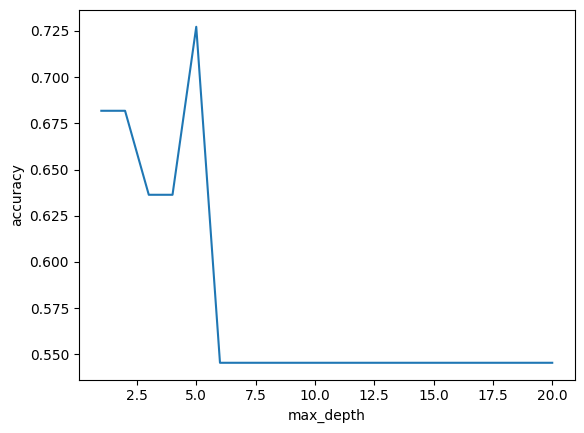

In [9]:
# Plot the accuracy vs depth
plt.plot(depths, acc_depth) 
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.show()

### Task 9

Find the largest accuracy and the depth this occurs.

In [10]:
# Find the largest accuracy and the depth this occurs
max_acc = np.max(acc_depth)
max_dep = depths[np.argmax(acc_depth)]
print(f'Highest accuracy {round(max_acc,3)*100}% at depth {max_dep}')

Highest accuracy 72.7% at depth 5


> **💡 Q&A — finding the best depth (my notes)**
>
> **Core idea:** `depths` (x) and `acc_depth` (y) are **parallel lists** — position `i` in one corresponds to position `i` in the other. So:
>
> 1. Find the **max value** in the y-list — `np.max(acc_depth)` looks for the maximum accuracy. But a value alone doesn't say *where* it is.
> 2. Get the **index** of that max in y — `np.argmax(acc_depth)` returns the position (the "index arg").
> 3. Use that index to read the **x-list** at the same position → the depth that produced the best accuracy.
>
> **The one-liner:** `depths[np.argmax(acc_depth)]`
>
> Read it inside-out: `argmax(acc_depth)` → best index in y → plug that index into `depths[...]` → the corresponding x-value. i.e. *"use the position of the max in y to pull the matching value out of x."*
>
> **My second note — the indexing idea:** writing `x[max_index_of(y)]` is a logic/condition that lands on the correct slot in the x-list and returns that x-value. (Wording fix: indexing with a *single position* like this is **positional indexing**, not boolean **masking** — masking is indexing with a whole True/False array, like `df[df.landmass.isin([3,6])]` back in Task 2. Same spirit of "select by a rule," different mechanism.)
>
> **Off-by-one watch:** `acc_depth` is indexed 0–19 but depths run 1–20. Letting `depths[index]` do the lookup avoids hand-counting the offset (`index + 1`) and never goes wrong.


### Task 10

Refit the decision tree model using the `max_depth` from above; plot the decision tree.

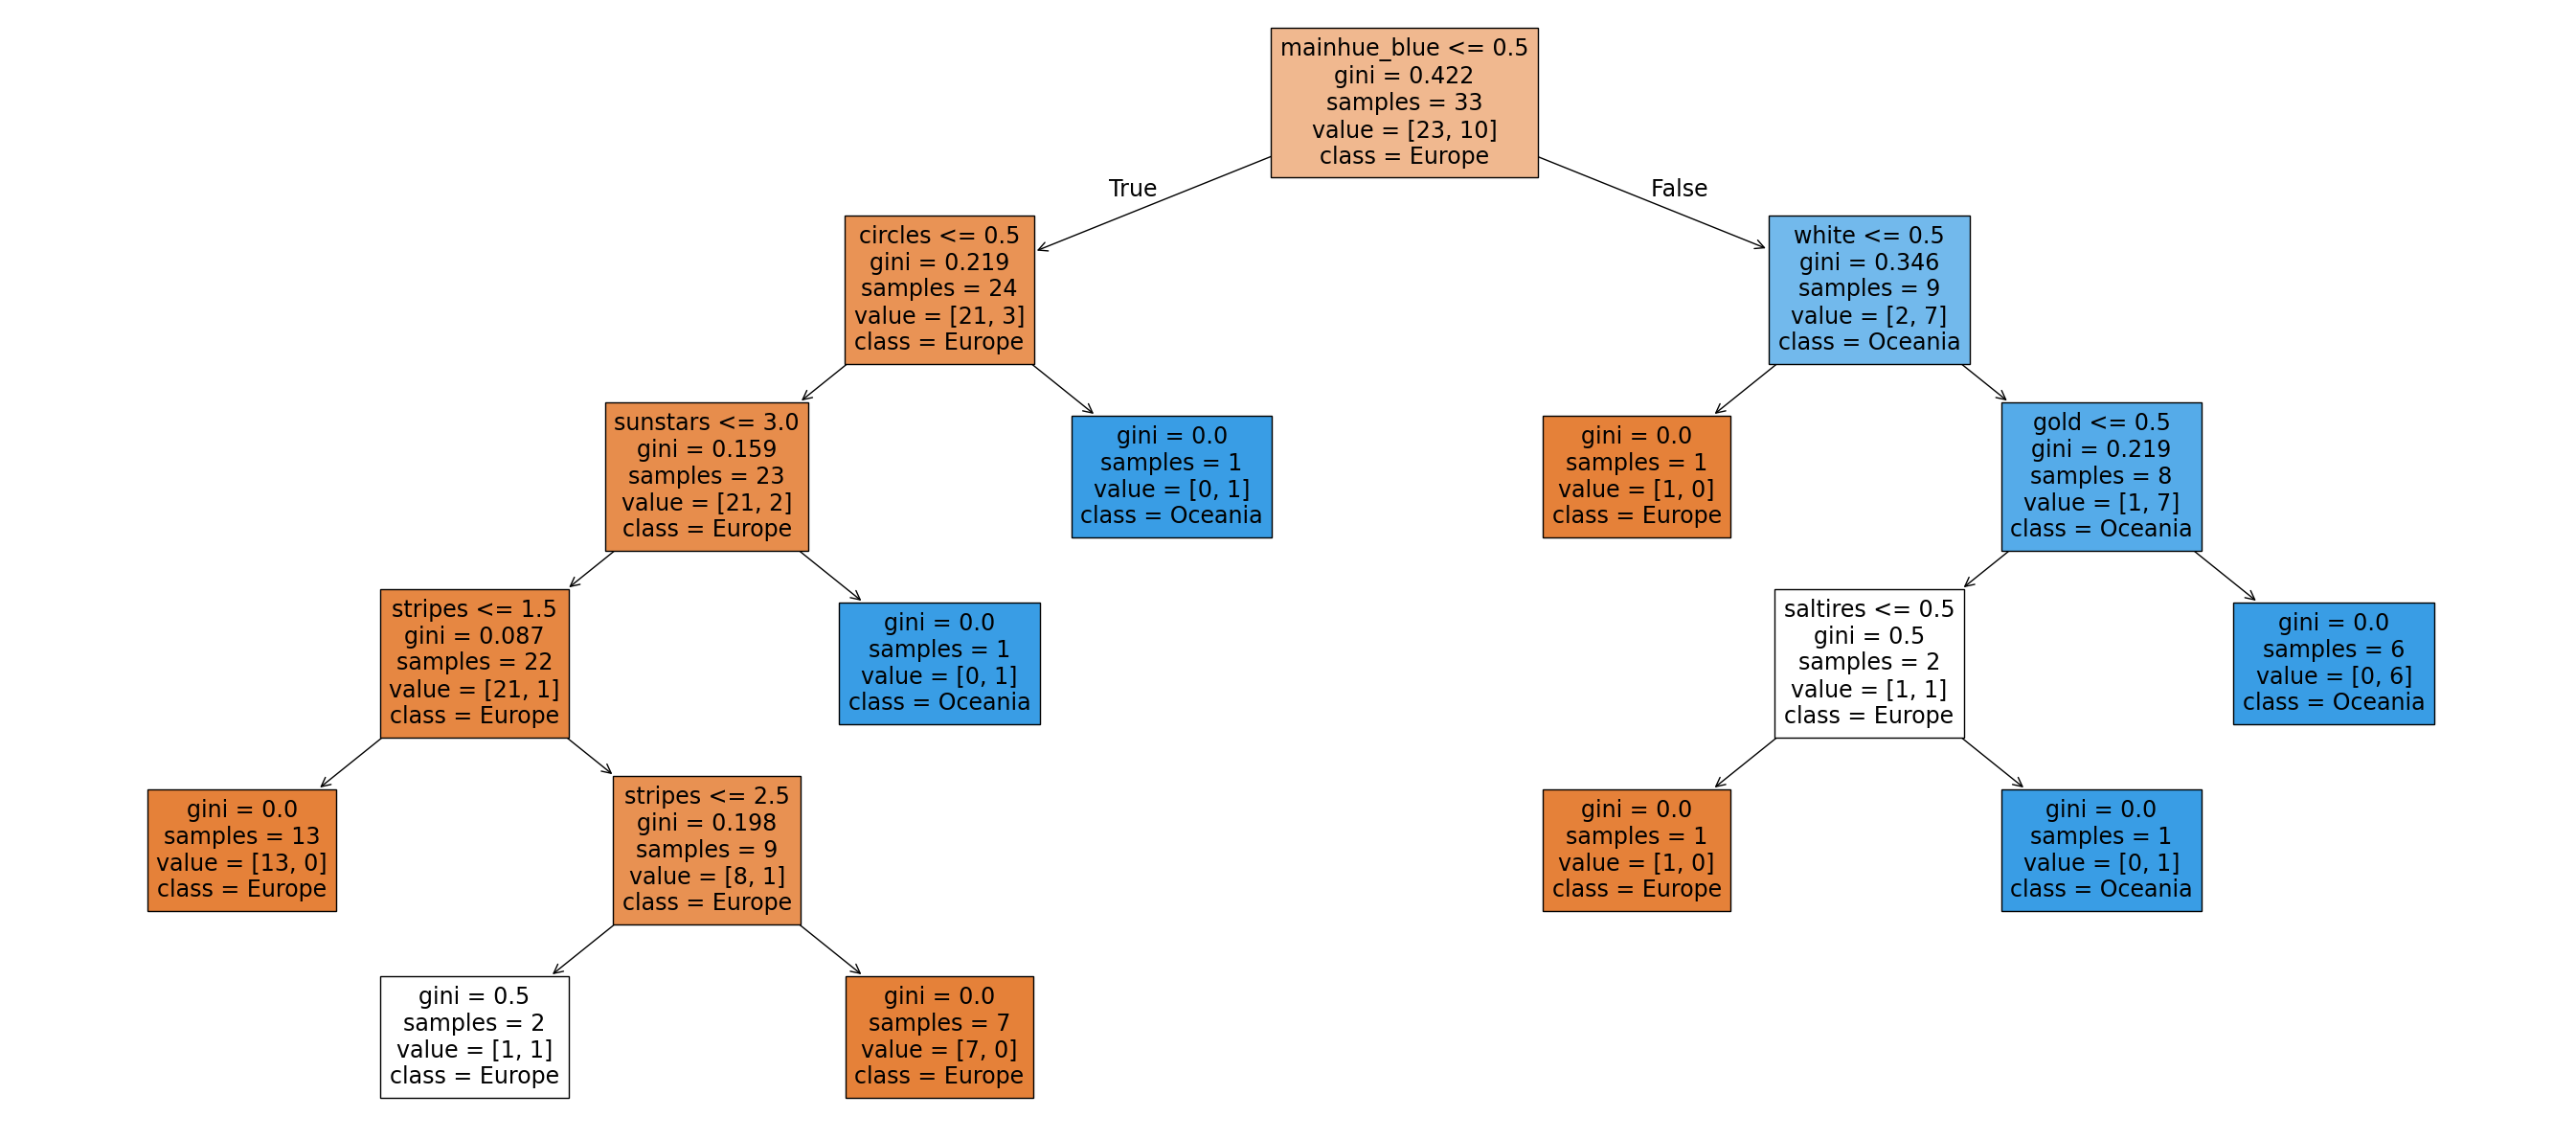

In [11]:
# Refit the decision tree model with the highest accuracy and plot the decision tree
dt = DecisionTreeClassifier(random_state = 10, max_depth = max_dep)
dt.fit(train_data, train_labels)
## Visualizing the tree
plt.figure(figsize=(27,12))
tree.plot_tree(dt, feature_names=train_data.columns, class_names=['Europe', 'Oceania'], filled=True)
plt.tight_layout()
plt.show()

> **💡 Q&A — `tree.plot_tree()` and its arguments**
>
> First, the easy-to-miss step: **the tree must be fitted before you can plot it.** A `DecisionTreeClassifier(...)` is just an empty shell of settings until `.fit()` grows the actual tree from data — so `dt.fit(train_data, train_labels)` has to run *before* `plot_tree(dt, ...)`, or you get `NotFittedError`.
>
> ```python
> tree.plot_tree(dt, feature_names=train_data.columns, class_names=['Europe', 'Oceania'], filled=True)
> ```
>
> - **`dt` (first, positional)** — the **fitted** estimator to draw. Positional, so no keyword.
> - **`feature_names=train_data.columns`** — labels the **split nodes**. Without it, nodes read `X[3] <= 0.5` (raw column index); with it they read the real name like `bars <= 0.5`. Pass `train_data.columns` because that's the exact set/order of columns the tree trained on (including the one-hot `mainhue_*` columns).
> - **`class_names=['Europe', 'Oceania']`** — labels the **predicted class** at each node. ⚠️ **Order gotcha:** this list maps to `dt.classes_`, which sklearn stores **sorted ascending**, *not* the order you typed. Our labels are raw landmass values `3` and `6`, so `classes_ = [3, 6]` → index 0 = `3` = Europe, index 1 = `6` = Oceania. So `['Europe', 'Oceania']` is correct here. Flip it and every leaf would be silently mislabeled while still *looking* fine. Sanity-check with `dt.classes_`.
> - **`filled=True`** — **colors** each node by its majority class; deeper color = purer node (more lopsided class mix). Makes the tree readable at a glance.
>
> Supporting calls: `plt.figure(figsize=(27,12))` gives a big canvas so nodes aren't cramped; `plt.tight_layout()` + `plt.show()` finish it off.


## Tune Decision Tree Classifiers by Pruning

### Task 11

Like we did with `max_depth`, we will now tune the tree by using the hyperparameter `ccp_alpha`, which is a pruning parameter. Fit a decision tree classifier for each value in `ccp`. Save the accuracy score in the list `acc_pruned`.

In [16]:
# Create a new list for the accuracy values of a pruned decision tree.  Loop through
# the values of ccp and append the scores to the list
ccp = np.logspace(-3, 0, num=20)
acc_pruned = []
for i in ccp: 
    dt_pruned = DecisionTreeClassifier(random_state = 10, max_depth = max_dep,  ccp_alpha=i)
    dt_pruned.fit(train_data, train_labels)
    acc_pruned.append(dt_pruned.score(test_data, test_labels))

> **💡 Q&A — what is a hyperparameter?**
>
> A **hyperparameter** is a setting *you* choose **before** training that controls *how* the model learns — as opposed to what the model learns *from* the data.
>
> | | **Parameters** | **Hyperparameters** |
> |---|---|---|
> | Who sets them | learned **by** the model | chosen **by you** |
> | When | *during* `.fit()` | *before* `.fit()` (constructor args) |
> | From the data? | yes | no |
> | Tree example | the actual splits (`bars ≤ 0.5`, leaf classes) | `max_depth`, `ccp_alpha`, `random_state`, `max_leaf_nodes` |
>
> **Why they matter here:**
> - They're the **knobs you tune** to balance **underfitting vs. overfitting**. `max_depth=1` → too simple, underfits (~68% in our plot); very deep → memorizes training noise, overfits (collapsed to ~55% on test). The sweet spot (depth 5) is found by *trying values* — that's what Tasks 7–9 did.
> - The model **can't learn them for you**, so you loop over a range and pick the best by test accuracy. That loop *is* hyperparameter tuning.
> - `ccp_alpha` (Task 11) is just another hyperparameter — it controls *how aggressively to prune* branches after the tree is grown. Same tuning game, different knob.
>
> **Analogy:** hyperparameters are the **oven settings** (temperature, time) you dial in before baking; parameters are the **cake** that comes out. You pick the settings; the data bakes the cake.


### Task 12

Plot the accuracy of the decision tree models versus the `ccp_alpha`.

*Hint: since `ccp` is on a log scale, `plt.xscale('log')` makes the plot easier to read.*

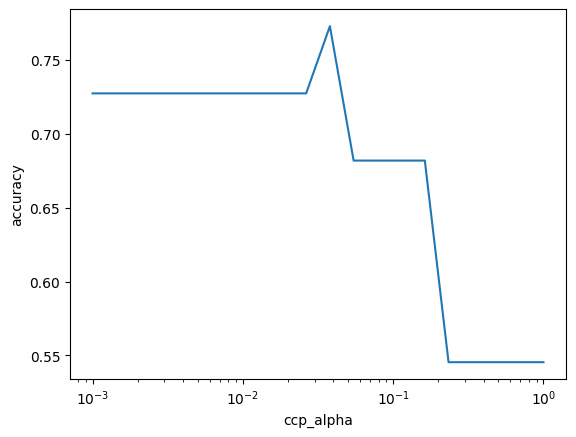

In [17]:
# Plot the accuracy vs ccp_alpha
plt.plot(ccp, acc_pruned)
plt.xscale('log')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.show()

### Task 13

Find the largest accuracy and the `ccp_alpha` value this occurs.

In [18]:
# Find the largest accuracy and the ccp value this occurs
max_acc_pruned = np.max(acc_pruned)
best_ccp = ccp[np.argmax(acc_pruned)]
print(f'Highest accuracy {round(max_acc_pruned,3)*100}% at ccp_alpha {round(best_ccp,4)}')

Highest accuracy 77.3% at ccp_alpha 0.0379


### Task 14

Fit a decision tree model with the values for `max_depth` and `ccp_alpha` found above. Plot the final decision tree.

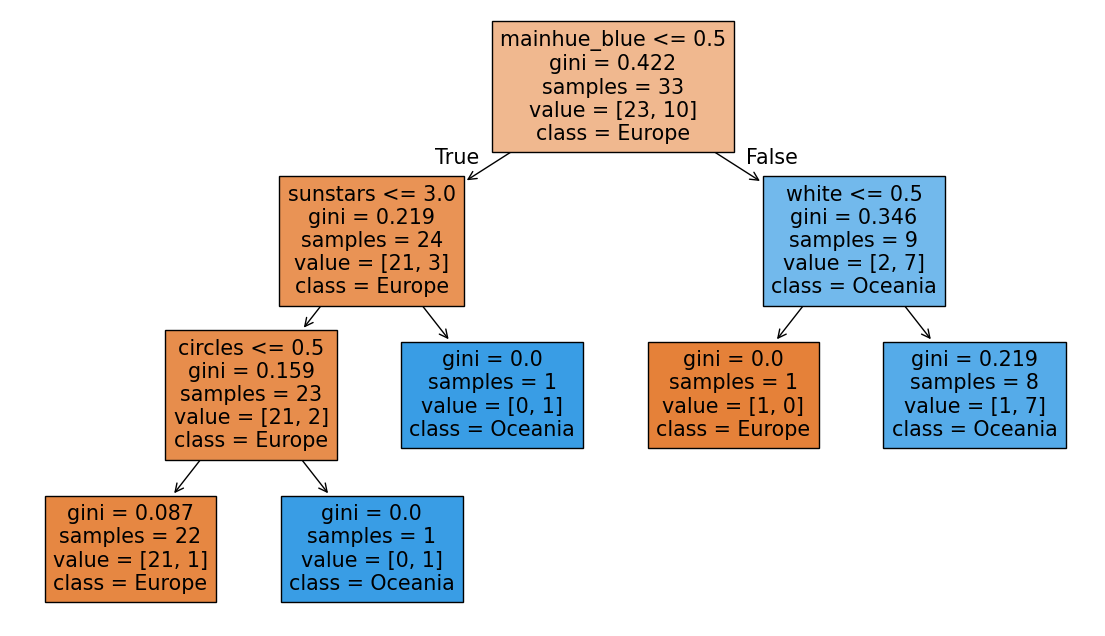

In [21]:
# Fit a decision tree model with the values for max_depth and ccp_alpha found above
dt_final = DecisionTreeClassifier(random_state = 1, max_depth = max_dep, ccp_alpha=best_ccp)
dt_final.fit(train_data, train_labels)
# Plot the final decision tree
plt.figure(figsize=(14,8))
tree.plot_tree(dt_final, feature_names = train_data.columns, class_names = ['Europe', 'Oceania'], filled=True)
plt.show()

### Task 15 — Wrap-up

Nice work! Note that the accuracy of our final model increased and the structure of the tree was simpler — many unnecessary branches were removed in the pruning process, making for a much easier interpretation.

**Ways to extend this project:**

- **Try to classify something else!** Rather than predicting `landmass`, could you predict something like `language`?
- **Find a subset of features** that work better than what we're currently using. Note that a categorical feature won't work very well as-is — we don't want a decision node splitting on whether `language` is above or below 5.
- **Tune more parameters** of the model — see the [DecisionTreeClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). For example, see what happens if you tune `max_leaf_nodes`. Think about whether you would be overfitting or underfitting based on how many leaf nodes you allow.